# Notebook 2: Preprocessing & Model Training on Real Sensor Data
*Authors: Sara Speelman & Andrei Covaci; 2026-03-11*  

In real world problems we often have to do quite some **preprocessing** before we can move on to the actual training and evaluation of our model. For today's problem, we have two different input datasets which we must first assemble to a single usable input dataset, before we can feed it to our model.  After assembling our dataset, we can continue with our ML workflow as usual.

We are using weather data obtained via a citizen science project to predict the temperature (TEMP). The people who choose the weather forecasting project, will be working with the vlinder data there as well. More info can be found on the [Vlinder project website](https://vlinder.ugent.be/) (vlinder is Dutch for butterfly).

We have one of those Vlinder stations on campus:


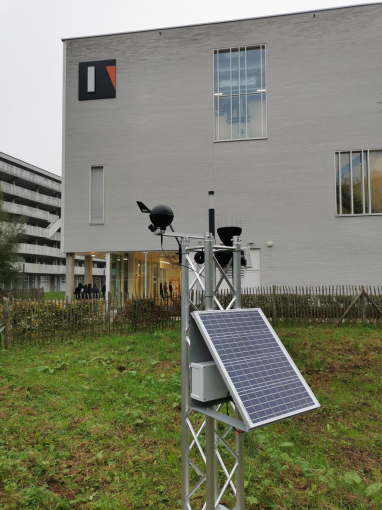


Learning outcomes:

- preprocessing deep dive: inspect and merge datasets with pandas
- ML workflow (new elements in **bold**):
    - global data inspection
    - data cleaning (types, missing values, duplicates)
    - use a **correlation matrix** in your EDA
    - create a correct train/val/test set for **time series data**
    - training and evaluating a model for a regression problem with time series data
    - using **scikit-learn's Pipeline** for the model workflow
    - **hyperparameter tuning** within the Pipeline

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import sklearn

random_state = 138
random.seed(random_state)

## 1. Global data inspection & merge

For this first part of the assignment we look at a handfull of commands from Pandas that might be useful for any ML problem (and particularly the weather forecasting assignment for this course). We will aproach this by assembling a dataframe from 2 different data sources: *df_vlinder.csv* and *df_synop.csv*. 
- **df_vlinder**: the weather observations retrieved via the citizen science project
- **df_synop**: data about the larger scale weather patterns at the same timesteps as the local observations in our vlinder dataset (cf. Synoptic scale weather patterns)

Your final result should be the same as the *df_merged.csv* file. You can use this file as a reference point.

The Pandas commands that you will use in this notebook:

- pandas.read_csv 
- pandas.to_datatime
- pandas.to_numeric
- pandas.DataFrame.rename
- pandas.DataFrame.head and DataFrame.tail 
- pandas.DataFrame.pop
- pandas.DataFrame.sort_values
- pandas.DataFrame.plot
- pandas.DataFrame.shape
- pandas.DataFrame.merge
- pandas.DataFrame.set_index
- pandas.DataFrame.isnull
- pandas.DataFrame.sum
- pandas.DataFrame.mean
- pandas.DataFrame.drop
- pandas.DataFrame.dropna
- pandas.DataFrame.resample
- pandas.DataFrame.corr

### 1.1 Inspect and merge de 2 dataframes

#### 1.1.0 Loading the datasets 
First, we need to load the three datasets. If you are using **Google Colab**, you can **upload the files to Google Drive** and the load the files from there as follows:

In [ ]:
## Mount Google Drive (if using Colab)
## Run this cell and give the necessary permissions to access your Google Drive. You can skip this step if you are running the notebook locally.
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
## Import the 3 datasets from your Google Drive (if you are using Colab)
## Adapt the file paths to your Google Drive.
# df_vlinder = pd.read_csv('/content/drive/MyDrive/<your_path>/df_vlinder.csv')
# df_synop = pd.read_csv('/content/drive/MyDrive/<your_path>/df_synop.csv')

You can also drag an drop the files to your workspace, and then read the csv files as in the cell below. But you'll have to redo this every time you open the notebook in Colab.

If you are **working locally**, save the data to the same directory as this notebook, and load them the following way:

In [ ]:
# DEMO
# Read the datasets (if you are running the notebook locally)
df_vlinder = pd.read_csv('df_vlinder.csv')
df_synop = pd.read_csv('df_synop.csv')

#### 1.1.1 Exploring df_vlinder

We have data of the observations of Vlinder station 16. We are interested in the following data at each time step:
- DATE
- TIME (UTC)
- TEMP: temperature
- PRECIP_QUANTITY: amount of precipitation
- PRESSURE: air pressure
- WIND_DIRECTION
- WIND_SPEED
- HUMIDITY_RELATIVE: relative humidity of the air
- Vlinder: indication of which "vlinder station" we are looking at.

Of course in an real life application you should always **think critically about feature selection**! Don't just rely on what you TA claims is relevant!

In [ ]:
# DEMO
# As it is a Dutch dataset, we rename the relevant columns to English
df_vlinder=df_vlinder.rename(columns={"Datum":"Date", "Tijd (UTC)":"Time (UTC)",
    "Temperatuur":"TEMP","Neerslagintensiteit": "PRECIP_QUANTITY", "Luchtdruk":"PRESSURE", "Windrichting": "WIND_DIRECTION",
                                    "Windsnelheid": "WIND_SPEED", "Vochtigheid":"HUMIDITY_RELATIVE" })

# The other columns can be deleted as they are not relevant for the prediction task. 
# Why is it important to only keep relevant columns?
cols_to_keep = ["Date", "Time (UTC)", "TEMP", "PRECIP_QUANTITY", "PRESSURE", "WIND_DIRECTION", "WIND_SPEED", "HUMIDITY_RELATIVE", "Vlinder"]
df_vlinder = df_vlinder[cols_to_keep]

In [ ]:
# EXERCISE
# Display the first rows of the dataframe


In [ ]:
# EXERCISE
# Display the last rows of the dataframe


We have the date (Date) and we have the time (Time (UTC)) in hour minutes and seconds. See if you can combine these into a datetime column. This will be usefull later on. 

In [ ]:
# EXERCISE
# Create a new datetime column from the Date and Time (UTC) columns 
df_vlinder['datetime']= ...

# Convert the column to datetime format
df_vlinder['datetime']= ...

# Remove the original Date and Time (UTC) columns


# Display the first rows of the dataframe


In [ ]:
# EXERCISE
# Sort the dataframe by datetime, to ensure chronological order
# HINT: use .reset_index(drop=True), otherwise the old index will be added as a new column, which we do not want
df_vlinder = ...

# Set datetime as index of the dataframe, meaning we will use it to reference the rows
df_vlinder= ...

We appear to have data from the beginning of June till the end of July. Let's have a look at the temperature (TEMP) observations

In [ ]:
# DEMO
# Plot TEMP over time, against the datetime
df_vlinder.plot(y='TEMP', figsize=(12, 4))
plt.xlabel('Datetime')
plt.ylabel('Temperature (TEMP)')
plt.title('Temperature over Time')
plt.grid()
plt.show()

In this figure we see the temperature at station vlinder 16 for June and July. Do we want to keep all this data? Which month would you prefer to work with?

In [ ]:
# DEMO
# Remove the month July (month 7) from df_vlinder based on the datetime column
df_vlinder = df_vlinder[df_vlinder.index.month != 7]
df_vlinder.tail()

In [ ]:
# EXERCISE
# Plot TEMP over time, against the datetime


We still seem to have some corrupted data. How would you deal with this?

In [ ]:
# DEMO
# One option is manually selecting a continuous period without missing target data
# Select only day 7 till 27 of June, to have a continuous period without missing target data
df_vlinder = df_vlinder[(df_vlinder.index >= '2020-06-06') & (df_vlinder.index < '2020-06-27')]
df_vlinder.plot(y='TEMP', figsize=(12, 4))
plt.xlabel('Datetime')
plt.ylabel('Temperature (TEMP)')
plt.title('Temperature over Time (June 6-26, 2020)')
plt.show()

The previous method is not ideal for large datasets (e.g. years of data, multiple stations) as it requires a lot of manual work. How else could we solve this issue?

We want to move to an hourly resolution, for compatibility with df_synop, which we will add later. How should we do this for precipitation (PRECIP_QUANTITY)?

In [ ]:
# DEMO
# Plot PRECIP_QUANTITY over time, against the datetime
df_vlinder.plot(y='PRECIP_QUANTITY', figsize=(12, 4))

In [ ]:
# EXERCISE
# first, separate PRECIP_QUANTITY from the dataframe, and turn into a separate dataframe: df_precip


In [ ]:
# EXERCISE
# print the first rows of the dataframe again, has PRECIP_QUANTITY been removed as expected?


In [ ]:
# DEMO
# Now, we resample both dataframes to hourly frequency. Why are we aggregating them both differently?
df_vlinder=df_vlinder.resample('60min').first()
df_precip=df_precip.resample('60min').sum()

In [ ]:
# EXERCISE
# Display the first rows of df_vlinder again, has the resampling worked as expected?


In [ ]:
# EXERCISE
# Display the first rows of df_precip again, has the resampling worked as expected?


In [ ]:
# EXERCISE
# Plot the resampled df_precip over time, against the datetime


Compare this plot to the previous plot of PRECIP_QUANTITY, what do you notice?

In [ ]:
# EXERCISE
# merge the two dataframes back together on the datetime column (which we have set as index)
df_vlinder = ...

In [ ]:
# EXERCISE
# final look at the dataframe, plot the first rows


#### 1.1.3 Adding df_synop
This data is a table with standard weather observations collected by professional weather stations at specific times and locations. We use it as context information: it gives a “big-picture” view (synoptic scale) of the weather at the same moment as our sensor measurements, which can help our model make better predictions. Our synoptic weather station is located in Stabroek, close to vlinder 16. We will use the temperature, wind speed and radiation information of this station.

In [ ]:
# DEMO
# for readability, we rename some columns
df_synop=df_synop.rename(columns={"temp":"TEMP_SYNOP","wind_speed":"WIND_SPEED_SYNOP","short_wave_from_sky_1hour":"RAD_SYNOP"})

In [ ]:
# EXERCISE
# print the first rows of the synoptic dataframe


In [ ]:
# EXERCISE
# check the type of the datetime column


In [ ]:
# EXERCISE
# convert the datetime column to datetime format


# set datetime as index of the synoptic dataframe


In [ ]:
# EXERCISE
# merge the synoptic dataframe with the vlinder dataframe (df_vlinder) on the datetime column (which should be the index of both dataframes)


In [ ]:
# EXERCISE
# final look at the first lines of the merged dataframe


### 1.2 Data Cleaning

#### 1.2.0 Optional - Comparing obtained with provided df_merged

Here, you can compare whether your df_merged looks like the provided df_merged. You don't have to add anything to the code. Just run the cells

We will continue with the provided dataset from here on.

In [ ]:
df_merged_old = df_merged.copy().reset_index(drop=False)

In [ ]:
# load the provided merged dataframe
df_merged=pd.read_csv('df_merged.csv', parse_dates=["datetime"])

In [ ]:
# Print the first values of df_merged_old to visually inspect them
print("DF_MERGED_OLD")
df_merged_old.head()


In [ ]:
# Print the first values of df_merged to visually inspect them
print("DF_MERGED")
df_merged.head()

In [ ]:
# Compare the columns of the two dataframes, are they the same?
# df_merged_old
print("DF_MERGED_OLD")
print(sorted(df_merged_old.columns))
print(len(df_merged_old.columns))
# df_merged
print("DF_MERGED")
print(sorted(df_merged.columns))
print(len(df_merged.columns))

In [ ]:
# Compare the indices of the two dataframes, are they the same?
print(df_merged_old.shape, df_merged.shape)
print(df_merged_old.index.equals(df_merged.index))

# Sort the columns to ensure they are in the same order for comparison
df_merged_old = df_merged_old.sort_index(axis=1)
df_merged = df_merged.sort_index(axis=1)
print(df_merged_old.columns.equals(df_merged.columns))

print((df_merged_old.dtypes == df_merged.dtypes).all())

# Test whether they are exactly the same
print(df_merged.equals(df_merged_old))

# Find the differences between the two dataframes
diff = df_merged_old.compare(df_merged)
diff.head(20)

#### 1.2.1 Actual data cleaning

First, we load the provided df_merged, so you can continue the exercises even if you did not finish 1.1 yet.

In [ ]:
## using Google Colab:
## load the provided merged dataframe from your Google Drive (if you are using Colab)
## Adapt the file paths to your Google Drive.
# df_merged = pd.read_csv('/content/drive/MyDrive/<your_path>/df_merged.csv', parse_dates=["datetime"])

In [ ]:
# Running locally:
# load the provided merged dataframe from your local directory
# ensure the "datetime" column is parsed as datetime format
df_merged=pd.read_csv('df_merged.csv', parse_dates=["datetime"])


In [ ]:
# EXERCISE
# print the first rows of the merged dataframe


In [ ]:
# EXERCISE
# Print the datatypes of each column

# Print the number of missing values in each column


We will have to handle the missing values in WIND_SPEED_SYNOP in our model. Here, we will remove this data. Removing these rows means throwing away 114 of the 504 rows, so if it were a course on data processing, we might recommend other methods. But this would take us too far.

In [ ]:
# DEMO
# Remove the time steps with missing values for 'WIND_SPEED_SYNOP'
df_merged = df_merged.dropna(subset=['WIND_SPEED_SYNOP'], ignore_index=True)

In [ ]:
# EXERCISE
# check for duplicate rows


# As we constructed the merged dataframe, we already know there are no duplicate columns

We will not need the following columns for training. Why is it important to remove these from the data set?

In [ ]:
# DEMO
df_final = df_merged.drop(columns=['Vlinder', 'community_name'])

Features that contain no useful information only add noise to a model, making learning harder, slower, and sometimes less accurate. Removing such features helps models focus on relevant patterns and improves both performance and interpretability.  

In [ ]:
# EXERCISE
# One final look at the final dataframe, print the first rows


## 2 Splitting our data into training and test set

In [ ]:
# DEMO
# Note: this cell is intentionally left commented

# df_train= df_final.loc[range(60,len(df_final))]
# df_test= df_final.loc[range(15,60)]

Is the previous block of code optimal. If not, what should be improved here?

In [ ]:
# EXERCISE
# split the dataframe into a training, validation and test set, taking into account that we are working with time series data
from sklearn.model_selection import train_test_split


Why would we set shuffle=False?  

In [ ]:
# DEMO
# Remove datetime column from train-val, train, val and test sets, store it for later use
train_val_datetime = df_train_val.pop('datetime')
train_datetime = df_train.pop('datetime')
val_datetime = df_val.pop('datetime')
test_datetime = df_test.pop('datetime')

Currently we are not using time as an input feature. Could you improve our training data by adding time information? How would you do this?

In [ ]:
# EXERCISE
# Splitting into X and y sets
target = "TEMP"

X_train = ...
y_train = ...

X_val = ...
y_val = ...

X_test = ...
y_test = ...

## 3. EDA on our training set, with correlation matrix

### 3.1 Summary statistics

In [ ]:
# EXERCISE
# Summary statistics of the target variable in the training set


In [ ]:
# EXERCISE
# Summary statistice of the features in the training set


### 3.2 Data Visualization

In [ ]:
# DEMO
# Plot the target variable in the training set over time, using the train_datetime variable we stored earlier
plt.figure(figsize=(12, 4))
plt.plot(train_datetime, y_train, marker='o', linestyle='-')
plt.xlabel('Datetime')
plt.ylabel('Temperature (TEMP)')
plt.title('Temperature over Time (Training Set)')
plt.grid()
plt.xticks(rotation=45)
plt.show()

In [ ]:
# EXERCISE
# Plot all 8 training features over time


### 3.3 Correlation matrix

Make a correlation matrix of our training set features. Why should we do this?

We will use the [seaborn](https://seaborn.pydata.org/) package, a package for statistical data visualization.

In [ ]:
# DEMO
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlations between the numeric columns
corr_matrix = X_train.corr()

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Matrix")
plt.show()

What does this correlation matrix tell us? Could highly correlated data affect our model in a way? How could we deal with this?
Have a look at the meaning of __[multicollinearity](https://www.geeksforgeeks.org/machine-learning/multicollinearity-in-data/)__.

## 4. Training, validation and testing

### 4.0 Baseline model

In [ ]:
# DEMO
# Baseline model: always predict the mean TEMP of the training set
baseline_temp = y_train.mean()

y_train_baseline_pred = np.full(len(y_train), baseline_temp)
y_val_baseline_pred = np.full(len(y_val), baseline_temp)
y_test_baseline_pred = np.full(len(y_test), baseline_temp)

### 4.1 KNeighborsRegressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

We want to predict TEMP using a **KNeighborsRegressor** (KNN).  
For a new data point, KNN regression finds the K training examples that are closest in feature space (using a chosen distance metric, e.g., Euclidean) and predicts the target as the average of their TEMP values (optionally weighted by distance, so closer neighbors count more).

If KNN is new to you, start with this [intro to KNN regression](https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbors-knn-regression-with-scikit-learn/), then read the [documentation of KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html).

#### 4.1.0 A note on feature scaling
Many machine learning models work better when **features are on a similar scale**. A common approach is to **standardize** each feature with [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html):

- centering: subtract the mean
- scaling: divide by the standard deviation

This gives features with approximately mean 0 and variance 1. Standardization is useful because some algorithms, such as SVMs and regularized linear models, are sensitive to feature scale. If one feature has much larger values or variance than the others, it can dominate the learning process and reduce model performance.  

#### 4.1.1 Introducing Pipeline

A **Pipeline** chains preprocessing and a model into a single object. During fit(), each preprocessing step is fit using only the training data (or CV fold) and then applied to transform the data before training the final estimator. This prevents data leakage into validation/test sets and makes workflows cleaner: you **call one fit() and one predict()**, and the pipeline applies the same transformations in the correct order every time.

For an introduction to Pipeline, have a look at [this article](https://shammeer.medium.com/mastering-scikit-learn-pipelines-4a54ef423c75) or [this one](https://www.geeksforgeeks.org/machine-learning/what-is-exactly-sklearnpipelinepipeline/).
Or immediately read the [documentation of Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

As an example of the usage of Pipeline, let's train our KNN model without any hyperparameter tuning. 

In [ ]:
# DEMO
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# Create Pipeline object with steps: scaling (StandardScaler) + KNN estimator
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

# Fit the pipeline on the training data
knn_pipeline.fit(X_train, y_train)

# Make predictions on the training and validation sets
y_train_pred = knn_pipeline.predict(X_train)
y_val_pred   = knn_pipeline.predict(X_val)

# Calculate RMSE for training and validation sets
from sklearn.metrics import mean_squared_error
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_val   = np.sqrt(mean_squared_error(y_val, y_val_pred))

# Print the RMSE results
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Val RMSE:   {rmse_val:.2f}")

Here, we randomly selected n_neighbors=5 as hyperparameter for our model. How could we improve this?

#### 4.1.2 Hyperparameter tuning (manually with loop)

**Hyperparameters** are model settings chosen before training (e.g., k in KNN, tree depth for a decision tree) that control the model’s behavior. Hyperparameter tuning is the process of testing different values (using a validation set or cross-validation) to pick the ones that generalize best to unseen data.

In this part we will evaluate the model for 20 different values of k on the validation set. With this we will determine which value would be optimal. We can do this within our **Pipeline** as well.

Write a block of code in which you use Pipeline to:
- scale the data (with StandardScaler)
- select KNN as our model (KNeighborsRegressor)
- Train our KNN model

In [ ]:
# EXERCISE
from sklearn.preprocessing import StandardScaler

# 1) Create Pipeline object with steps: scaling (StandardScaler) + KNN estimator
knn_pipeline = Pipeline([
    ("scaler", ...),
    ("knn", ...)
])

# 2) Hyperparameter tuning workflow
# Set the range of k values to test 
neighbors = range(1, 21)

# Loop over different values of k
train_rmses = []
val_rmses = []
for k in neighbors:
    # Set the number of neighbors in the KNN model
    # HINT: use knn_pipeline.set_params(...)
    # HINT: A Pipeline has named steps. To change a setting inside a step, scikit-learn uses: stepname__parametername
    # HINT: knn = the name of the step in the pipeline, n_neighbors = the parameter of KNeighborsRegressor
    ...

    # Fit the pipeline on the training data
    

    # Make predictions on the training and validation set


    # Calculate RMSE for training and validation sets


    # Append to the lists of RMSEs for training and validation sets


# 3) Find the best k value, based on the minimum validation RMSE

# Print the best k value found


# 4) Plot validation RMSE vs k
plt.plot(neighbors, val_rmses, marker='o', label='Val RMSE')
plt.plot(neighbors, train_rmses, marker='o', label='Train RMSE')
plt.xlabel("Number of Neighbors k")
plt.ylabel("RMSE")
plt.title("KNN Hyperparameter Tuning")
plt.grid()
plt.legend()
plt.show()

Can you interpret the resulting plot? Why does training RMSE increase for increasing k? Can you relate this result to overfitting and underfitting?

We don't have a lot of data, so the result on our validation set might not be statistically significant. Maybe we were just lucky with the result on this dataset. How can we improve the robustness of the result?

#### 4.1.3 Hyperparameter tuning with GridSearch and cross validation


Cross-validation is a smarter approach for hyperparameter tuning on our small dataset. In reality, you would of course immediately use cross-validation, instead of the detour we took here for teaching purposes.

##### Introduction to TimeSeriesSplit for CV

As we are working with **time series data**, we must ensure we do not randomly shuffle our data when creating folds for CrossValidation. Could you explain why?   
**TimeSeriesSplit** performs cross-validation by creating folds where each training fold contains earlier time points and each validation fold contains later time points, which avoids “peeking into the future.”

Read the [documentation of TimeSeriesSplit](https://scikit-learn.org/stable/modules/cross_validation.html#time-series-split).

In [ ]:
# DEMO
from sklearn.model_selection import TimeSeriesSplit
# Create a 'Time series cross-validation' object with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# DEMO
tscv

Could you improve this split even more? Discuss with your neighbours.

##### GridSearchCV

We can improve our methodology for hyperparameter tuning using **GridSearchCV**. GridSearchCV is a wrapper around your model. It will:  
- try all possible combinations of the specified parameter values
- evaluate each using cross-validation
- keep the best hyperparameter combination, and refit the model on the trainval set

Read the [documentation of GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html). 
We encourage you to have a look at other options as well, e.g. **RandomizedSearchCV** and HalvingGridSearchCV as well.

In [ ]:
# EXERCISE
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error

# We use the combined training and validation sets for cross-validation
# Using df_train_val to create X_train and y_train
X_train_val = ...
y_train_val = ...

# 1) Pipeline object: scaling + KNN
knn_pipeline = Pipeline([
    ("scaler", ...),
    ("knn", ...)
])

# 2) Time series split object
tscv = ...

# 3) Hyperparameter grid
# we specify the esimator name in the pipeline (knn) followed by the parameter name (n_neighbors) 
param_grid = ...

# 4) Create grid search CV object with time-series CV
grid = GridSearchCV(
    estimator= ...,
    param_grid= ...,
    cv= ...,
    scoring= ..., # scoring metric to optimize (look up the correct name for RMSE in scikit-learn)
    return_train_score=True # whether to return the training scores as well
)

# 5) Fit the grid search object on the combined training and validation data



GridSearchCV has refit=True by default, meaning it automatically retrains on the trainval set, using the best params.

- `grid.best_params` -> the best hyperparameters
- `grid.best_score` -> Mean cross-validated score of the best_estimator
- `grid.best_estimator` -> the final model refit on the entire trainval set
- `grid.predict`(..) -> use the refit model to make predictions on a new dataset

In [ ]:
# DEMO
print("Best k:", grid.best_params_["knn__n_neighbors"])
print("Best CV RMSE:", round(-grid.best_score_, 3))

In [ ]:
# DEMO
# Plot mean RMSE over folds for each k tested in GridSearchCV
mean_cv_rmse = -grid.cv_results_['mean_test_score']  # scikit-learn stores RMSE as negative when using neg_root_mean_squared_error

param_name = list(param_grid.keys())[0]
param_values = param_grid[param_name]

plt.figure(figsize=(8, 5))
plt.plot(param_values, mean_cv_rmse, marker='o', label='Mean CV RMSE')

if 'mean_train_score' in grid.cv_results_:
    mean_train_rmse = -grid.cv_results_['mean_train_score']
    plt.plot(param_values, mean_train_rmse, marker='o', label='Mean Train RMSE')
else:
    print("mean_train_score not available. Refit GridSearchCV with return_train_score=True to plot train RMSE.")

plt.xlabel(param_name)
plt.ylabel("RMSE")
plt.title("Mean RMSE vs hyperparameter (GridSearchCV)")
plt.grid()
plt.legend()
plt.show()

Let's compare our final KNN model with the baseline model:

In [ ]:
# DEMO
# Baseline model performance with the same CV strategy (TimeSeriesSplit)
cv_baseline_rmses = []

for train_idx, val_idx in tscv.split(y_train_val):
    y_train_fold = y_train_val.iloc[train_idx]
    y_val_fold = y_train_val.iloc[val_idx]

    fold_mean_temp = y_train_fold.mean()  # baseline fitted on training fold only
    y_val_fold_pred = np.full(len(y_val_fold), fold_mean_temp)

    fold_rmse = np.sqrt(np.mean((y_val_fold - y_val_fold_pred) ** 2))
    cv_baseline_rmses.append(float(fold_rmse))

print(f"Baseline CV RMSE (mean): {np.mean(cv_baseline_rmses):.3f}")
print(f"Baseline CV RMSE (per fold): {[round(r, 3) for r in cv_baseline_rmses]}")

Luckily, our KNN model beat the baseline (train mean) model.

#### 4.1.4 Final performance evaluation on the test set

In [ ]:
# EXERCISE
# Make predictions on the test set using the best estimator from GridSearchCV
y_pred = ...

In [ ]:
# EXERCISE
# Get the actual Y values from the test set
y_true = ...

In [ ]:
# EXERCISE
# Plot actual vs predicted TEMP values on the test set
import matplotlib.pyplot as plt



Final part:
Calculate the mean absolute error (MAE), root mean squared error (RMSE) and bias.


Do these values match the figure above? What could we do to improve these values and our prediction in general?

In [ ]:
# EXERCISE
from sklearn.metrics import mean_absolute_error
# Calculate and print the RMSE on the test set


# Calculate and print the MAE on the test set


# Calculate and print the bias (average error) on the test set


Some things to think about here:

- Is it necessary to scale the data?
- Why is the RMSE bigger when looking at the model performance on the test set?
- Why is the performance of the model so dissapointing in general?

A plot of our full data set might help to gain some insight here.

In [ ]:
# DEMO
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(train_datetime, y_train, color='green', label='Train TEMP')
plt.plot(val_datetime, y_val, color='blue', label='Validation TEMP')
plt.plot(test_datetime, y_test, color='red', label='Test TEMP')
plt.xlabel('Datetime')
plt.ylabel('Temperature (TEMP)')
plt.title('TEMP over Time: Train (green), Validation (blue), Test (red)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Our test set is not a representative sample of our dataset, the average temperature is much higher here. Many of the observed y_test values are outside of the range of the TEMP values our model has seen. The bias of our model tells us that our model underestimates the observed temperature, which is to be expected if we look at the above figure. 

However, a generalization error is always to be expected. A model is optimized on the training+validation data, and won't perform as well on unseen data.

### 4.2 Extra: DecisionTreeRegressor

Read the [documentation of DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html).

#### 4.2.1 Hyperparameter tuning with GridSearch and cross-validation

Here, we try different values for `max_depth` of our decision tree. Why does this parameter matter?

In [ ]:
# EXERCISE
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error

# We use the combined training and validation sets for cross-validation
# Using df_train_val to create X_train and y_train


# 1) Pipeline opbject: scaling + Decision Tree

# 2) Time series split object


# 3) Hyperparameter grid )


# 4) Grid search CV object with time-series CV


# 5) Fit the grid search object on the combined training and validation data



In [ ]:
# EXERCISE
# Print the best max_depth value found and the corresponding CV RMSE


In [ ]:
# EXERCISE
# Plot mean RMSE over folds for each max_depth tested in GridSearchCV


What does this curve of mean training and validation score for different max_depths tell you?

#### 4.2.1 Final performance evaluation on test set

In [ ]:
# EXERCISE
# Make predictions on the test set using the best estimator from GridSearchCV

# Get the actual Y values from the test set


In [ ]:
# EXERCISE
# Plot actual vs predicted TEMP values on the test set
import matplotlib.pyplot as plt



Why would the predicted temperature by our decision tree model be capped?

In [ ]:
# EXERCISE
# Calculate and print the RMSE on the test set


# Calculate and print the MAE on the test set


# Calculate and print the bias on the test set


**Disclaimer**: GenAI was used to restructure and improve the content of this notebook.
